In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import datetime
import random

In [3]:
df = pd.read_csv(r'D:\Documents Learning\SCA\synthetic_beverage_sales_data.csv')
df.head(10)

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23
5,ORD2,CUS2847,B2C,Sauvignon Blanc,Alcoholic Beverages,9.09,2,0.00,18.18,Schleswig-Holstein,2023-03-16
6,ORD3,CUS1806,B2B,Tomato Juice,Juices,2.14,44,0.10,84.74,Hamburg,2022-11-20
7,ORD3,CUS1806,B2B,Vittel,Water,0.43,13,0.05,5.31,Hamburg,2022-11-20
8,ORD3,CUS1806,B2B,San Pellegrino,Water,1.21,92,0.10,100.19,Hamburg,2022-11-20
9,ORD3,CUS1806,B2B,Evian,Water,1.38,3,0.05,3.93,Hamburg,2022-11-20


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8999910 entries, 0 to 8999909
Data columns (total 11 columns):
 #   Column         Dtype  
---  ------         -----  
 0   Order_ID       object 
 1   Customer_ID    object 
 2   Customer_Type  object 
 3   Product        object 
 4   Category       object 
 5   Unit_Price     float64
 6   Quantity       int64  
 7   Discount       float64
 8   Total_Price    float64
 9   Region         object 
 10  Order_Date     object 
dtypes: float64(3), int64(1), object(7)
memory usage: 755.3+ MB


In [5]:
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe(include='all')

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
count,8999910,8999910,8999910,8999910,8999910,8999910.00,8999910.00,8999910.00,8999910.00,8999910,8999910
unique,3000000,10000,2,47,4,NaN,NaN,NaN,NaN,16,1094
top,ORD1,CUS4693,B2C,Hohes C Orange,Alcoholic Beverages,NaN,NaN,NaN,NaN,Hamburg,2023-06-22
freq,5,1120,5795405,337114,2251625,NaN,NaN,NaN,NaN,604054,8749
mean,NaN,NaN,NaN,NaN,NaN,5.82,23.14,0.03,130.74,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,14.70,26.89,0.04,509.69,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,0.32,1.00,0.00,0.30,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,1.05,6.00,0.00,8.40,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,1.75,11.00,0.00,21.14,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,3.21,30.00,0.05,69.49,NaN,NaN


In [6]:
df.isnull().sum()

Order_ID         0
Customer_ID      0
Customer_Type    0
Product          0
Category         0
Unit_Price       0
Quantity         0
Discount         0
Total_Price      0
Region           0
Order_Date       0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df = df.convert_dtypes()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8999910 entries, 0 to 8999909
Data columns (total 11 columns):
 #   Column         Dtype  
---  ------         -----  
 0   Order_ID       string 
 1   Customer_ID    string 
 2   Customer_Type  string 
 3   Product        string 
 4   Category       string 
 5   Unit_Price     Float64
 6   Quantity       Int64  
 7   Discount       Float64
 8   Total_Price    Float64
 9   Region         string 
 10  Order_Date     string 
dtypes: Float64(3), Int64(1), string(7)
memory usage: 789.6 MB


In [9]:
df['Order_ID'] = df['Order_ID'].str[3:].astype('int')
df['Customer_ID'] = df['Customer_ID'].str[3:].astype('int')
df['Customer_Type'] = df['Customer_Type'].astype('category')
df['Category'] = df['Category'].astype('category')
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%Y-%m-%d')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8999910 entries, 0 to 8999909
Data columns (total 11 columns):
 #   Column         Dtype         
---  ------         -----         
 0   Order_ID       int32         
 1   Customer_ID    int32         
 2   Customer_Type  category      
 3   Product        string        
 4   Category       category      
 5   Unit_Price     Float64       
 6   Quantity       Int64         
 7   Discount       Float64       
 8   Total_Price    Float64       
 9   Region         string        
 10  Order_Date     datetime64[ns]
dtypes: Float64(3), Int64(1), category(2), datetime64[ns](1), int32(2), string(2)
memory usage: 600.8 MB


###   EDA: 

##### Overall:
1. Total sales and total quantities by customer type
2. Total sales and total quantities by product
3. Total sales and total quantities by category
4. Total sales and total quantities by region

##### Overtime:
5. Total sales over time
6. Total sales and total quantities of each category over time
7. Total sales by customer_id
8. Total quanties by customer id

##### Price and Discount
9. Price and Discount vs Quantity sold in a order


#### Total sales and total quantites by Customer types

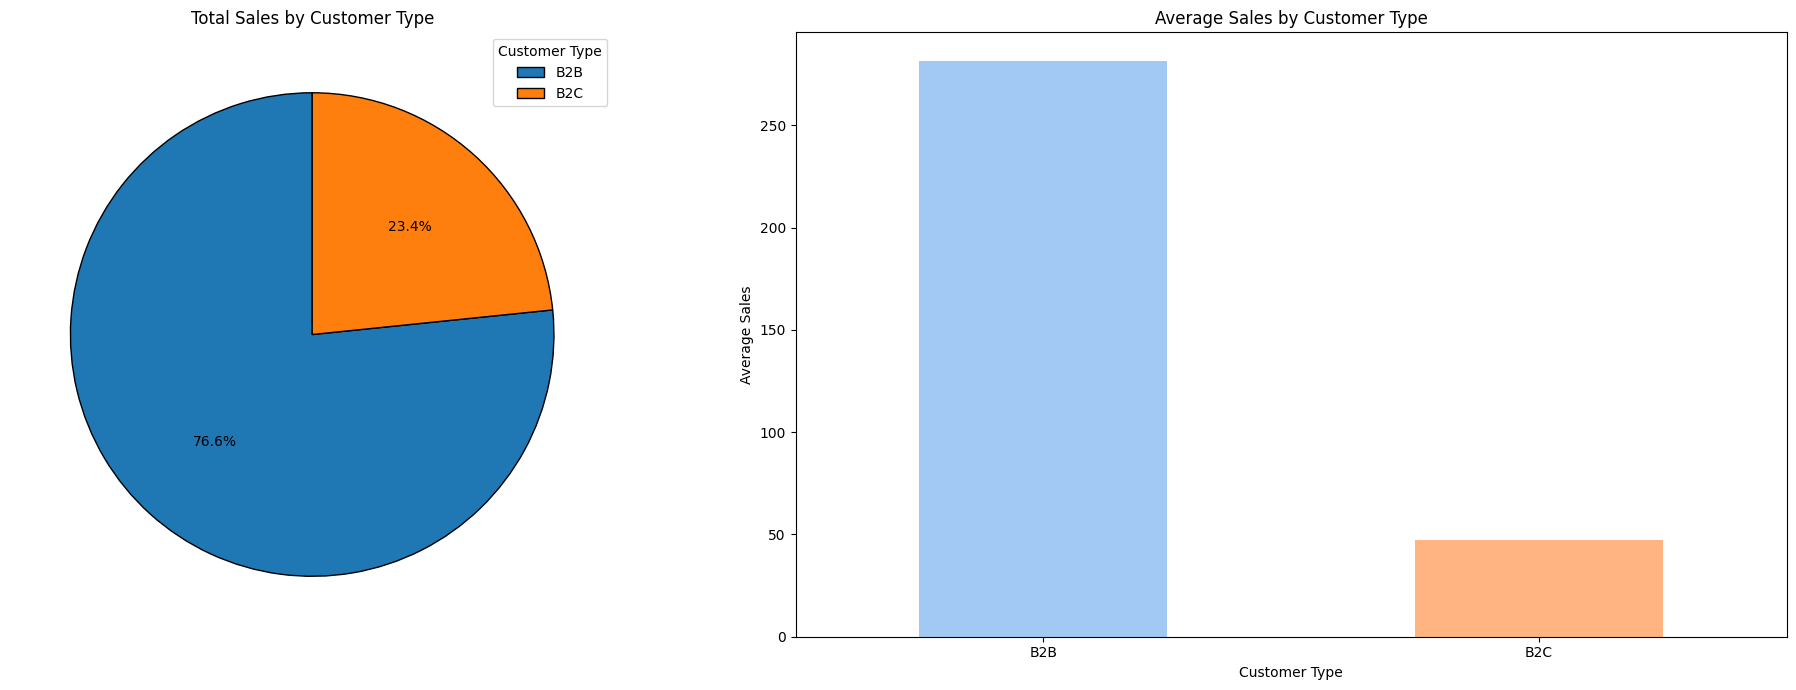

In [10]:
# Calculate the required data
customer_sales = df.groupby('Customer_Type', observed=True)['Total_Price'].sum()
avg_customer_sales = df.groupby('Customer_Type', observed=True)['Total_Price'].mean()

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 7)) # 1 row, 2 columns

# First subplot: Pie chart for total sales
sns.set_palette('pastel')
axes[0].pie(
    customer_sales,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)
axes[0].set_title('Total Sales by Customer Type')
axes[0].set_ylabel('')
axes[0].legend(title='Customer Type', loc='upper right', labels=customer_sales.index)

# Second subplot: Bar chart for average sales
colors = sns.color_palette('pastel', n_colors=len(avg_customer_sales))
avg_customer_sales.plot(kind='bar', color=colors, ax=axes[1]) # Use the second axes object
axes[1].set_title('Average Sales by Customer Type')
axes[1].set_xlabel('Customer Type')
axes[1].set_ylabel('Average Sales')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show();

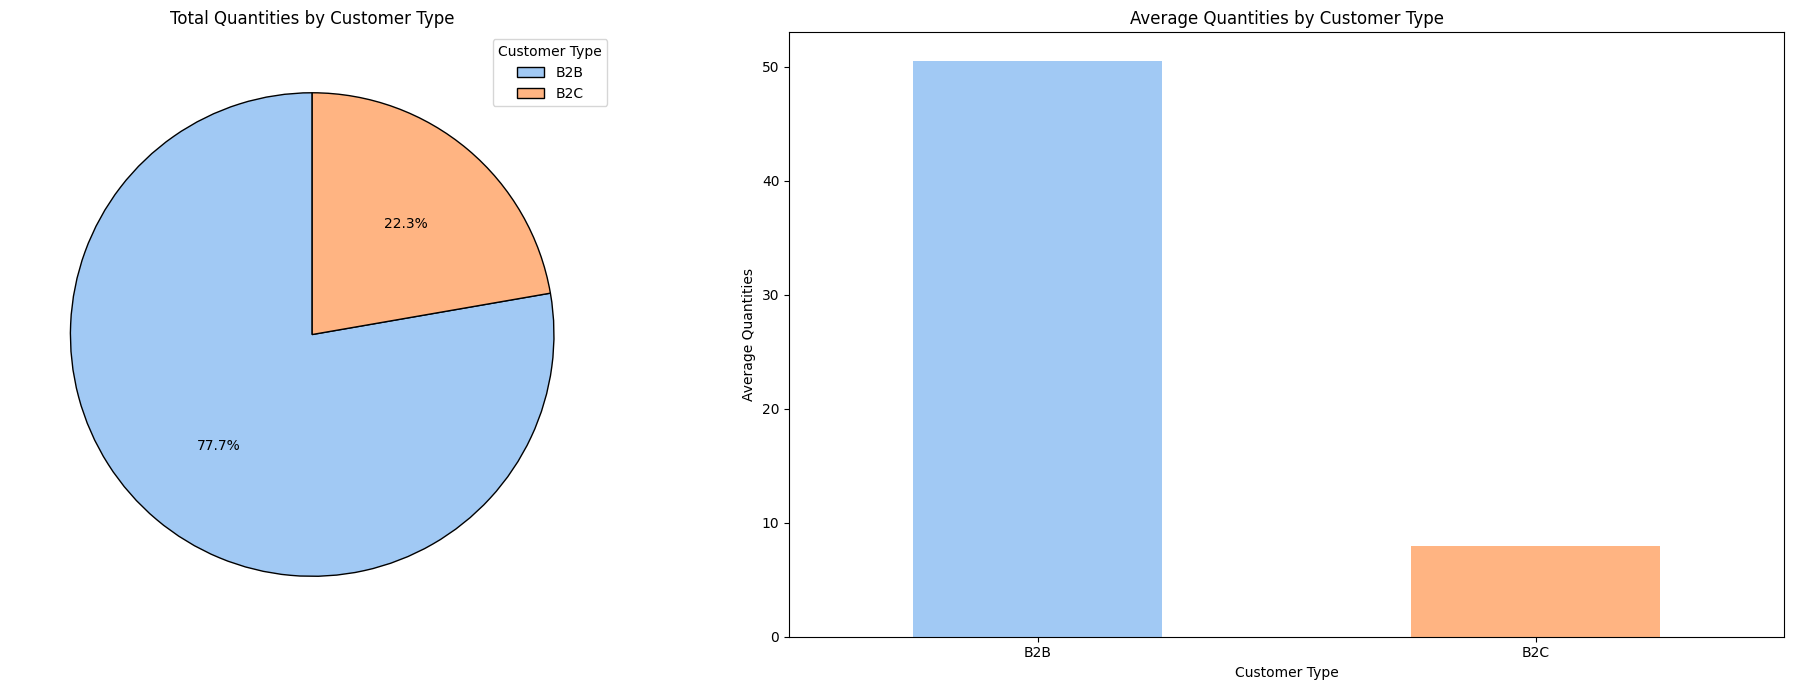

In [11]:
# Calculate the required data
customer_quantities = df.groupby('Customer_Type', observed=True)['Quantity'].sum()
avg_customer_quantities = df.groupby('Customer_Type', observed=True)['Quantity'].mean()

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 7)) # 1 row, 2 columns

# First subplot: Pie chart for total sales
sns.set_palette('pastel')
axes[0].pie(
    customer_quantities,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)
axes[0].set_title('Total Quantities by Customer Type')
axes[0].set_ylabel('')
axes[0].legend(title='Customer Type', loc='upper right', labels=customer_quantities.index)

# Second subplot: Bar chart for average sales
colors = sns.color_palette('pastel', n_colors=len(avg_customer_sales))
avg_customer_quantities.plot(kind='bar', color=colors, ax=axes[1])
axes[1].set_title('Average Quantities by Customer Type')
axes[1].set_xlabel('Customer Type')
axes[1].set_ylabel('Average Quantities')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout() 
plt.show();

#### Total sales and quantities by Products

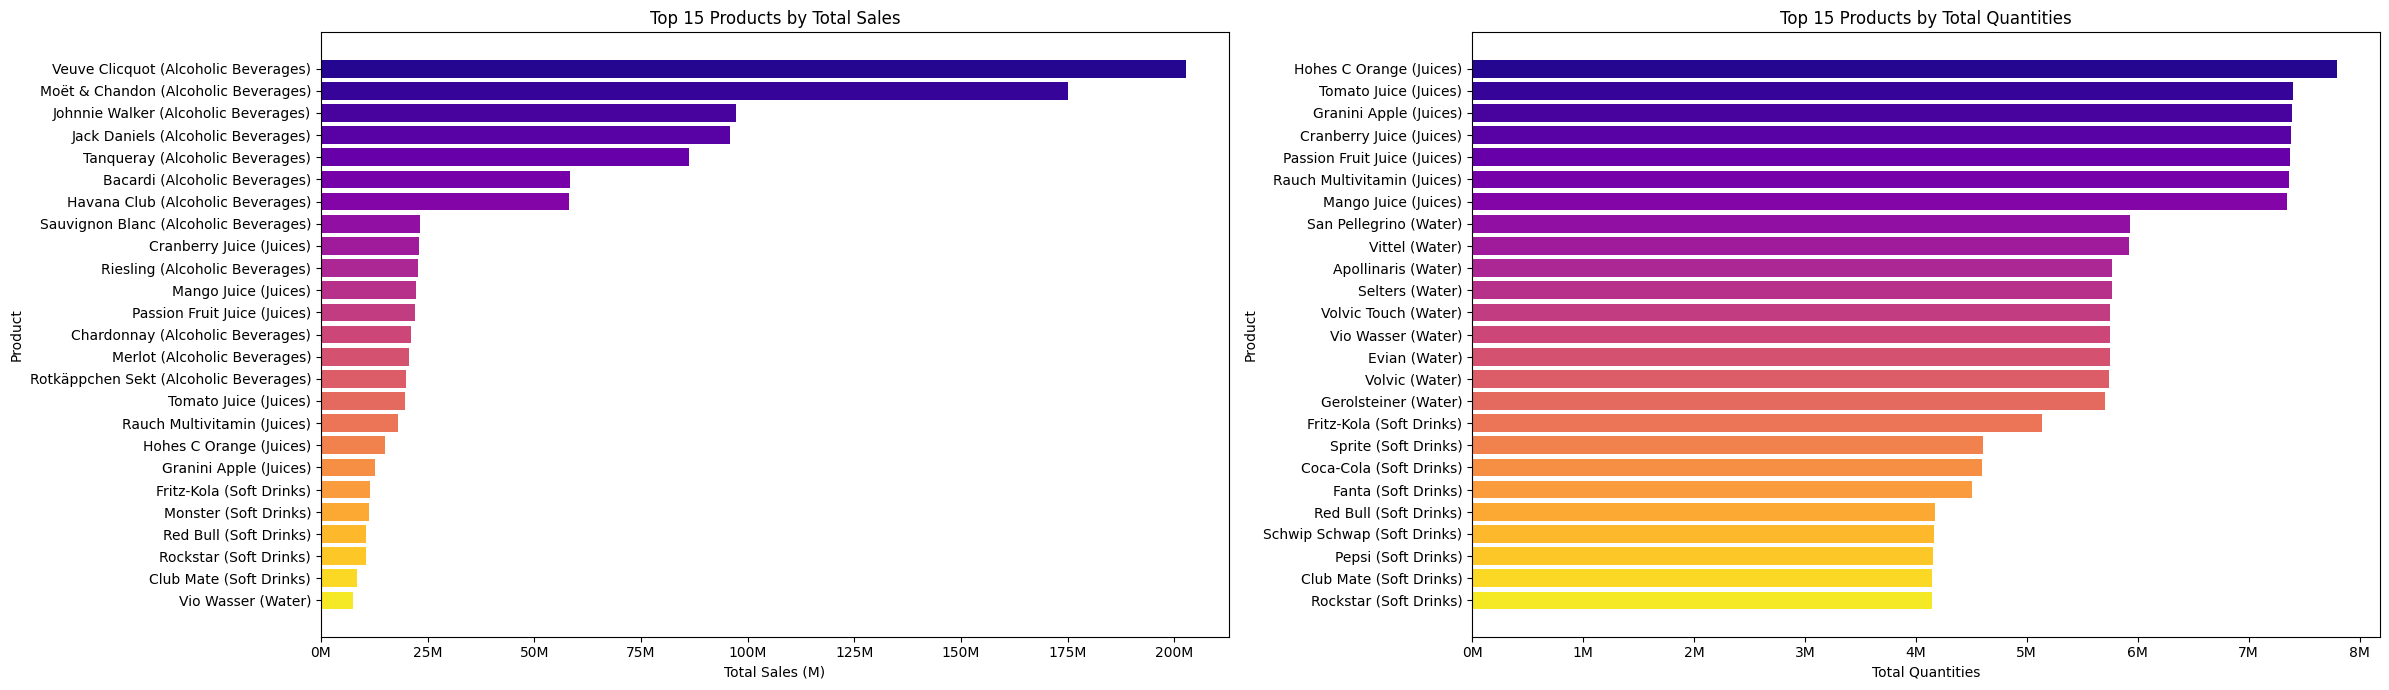

In [12]:
# Calculate the required data and merge with Category
product_sales = df.groupby('Product')['Total_Price'].sum().sort_values(ascending=False).head(25)
product_quantities = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(25)

# Get the category for each of the top products
sales_categories = df.groupby('Product')['Category'].first()[product_sales.index]
quantity_categories = df.groupby('Product')['Category'].first()[product_quantities.index]

# Create new labels with product name and category
sales_labels = [f"{product} ({category})" for product, category in sales_categories.items()]
quantity_labels = [f"{product} ({category})" for product, category in quantity_categories.items()]

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(24, 7)) # Adjust figsize as needed

# First subplot: Top 15 Products by Total Sales
colors_sales = sns.color_palette('plasma', n_colors=len(product_sales))
axes[0].barh(sales_labels, product_sales.values, color=colors_sales) # Use the new labels
axes[0].set_xlabel('Total Sales (M)')
axes[0].set_ylabel('Product')
axes[0].set_title('Top 15 Products by Total Sales')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: '%1.0fM' % (x * 1e-6)))
axes[0].invert_yaxis()

# Second subplot: Top 15 Products by Total Quantities
colors_quantities = sns.color_palette('plasma', n_colors=len(product_quantities))
axes[1].barh(quantity_labels, product_quantities.values, color=colors_quantities) # Use the new labels
axes[1].set_xlabel('Total Quantities')
axes[1].set_ylabel('Product')
axes[1].set_title('Top 15 Products by Total Quantities')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: '%1.0fM' % (x * 1e-6)))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

#### Total sales and total quantities by Categories

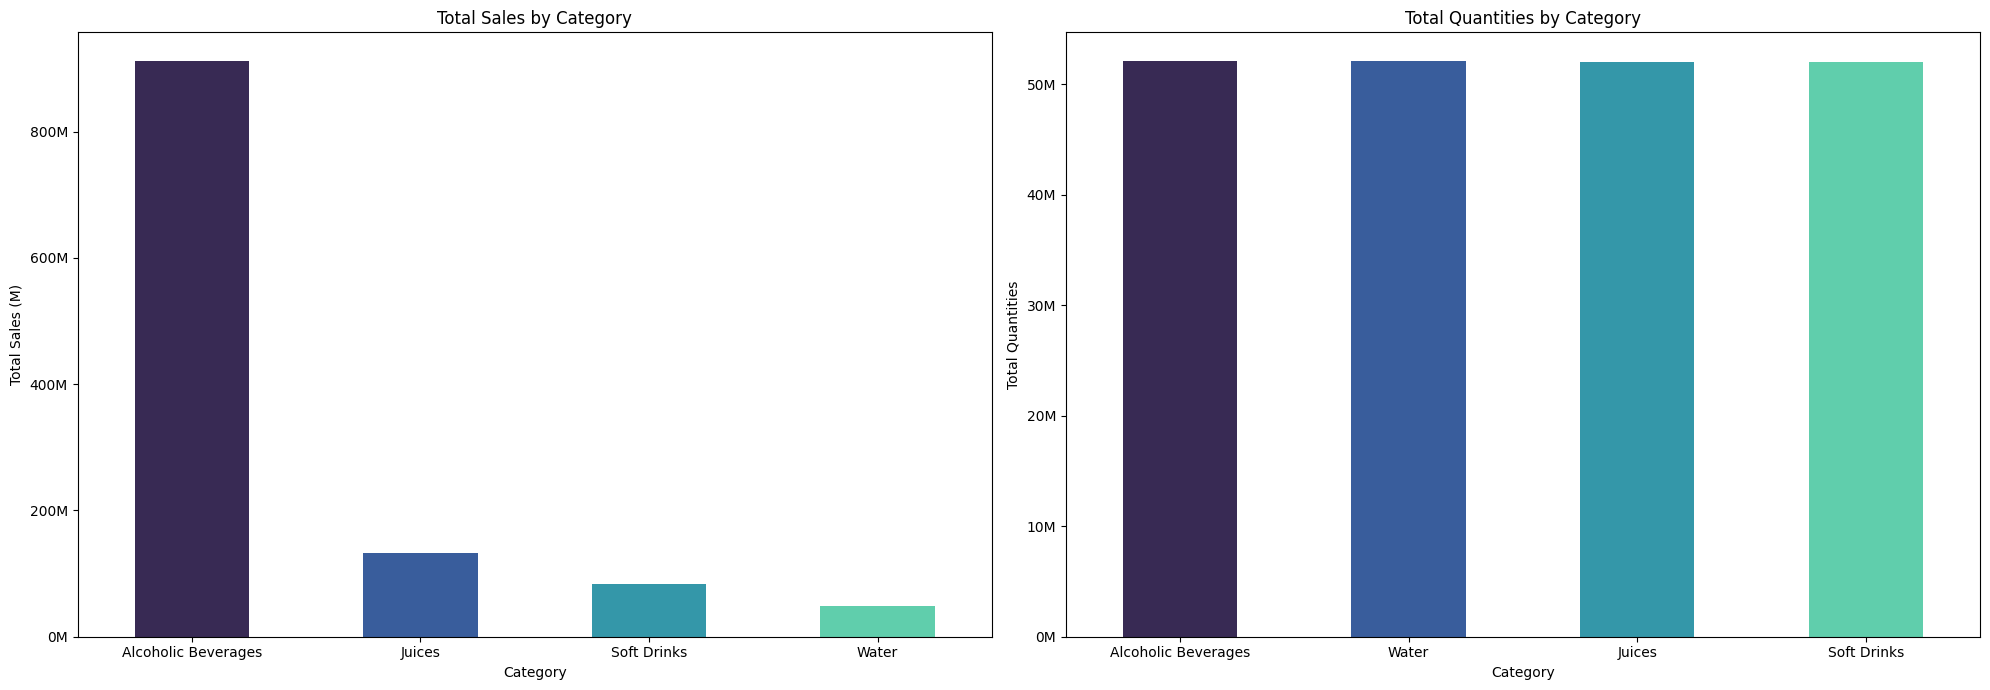

In [13]:
# Calculate the required data
category_sales = df.groupby('Category', observed=True)['Total_Price'].sum().sort_values(ascending=False)
category_quantities = df.groupby('Category', observed=True)['Quantity'].sum().sort_values(ascending=False)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 7)) # Adjust figsize as needed

# First subplot: Total Sales by Category
colors_sales = sns.color_palette('mako', n_colors=len(category_sales))
category_sales.plot(kind='bar', color=colors_sales, ax=axes[0])
axes[0].set_title('Total Sales by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales (M)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: '%1.0fM' % (x * 1e-6)))
axes[0].tick_params(axis='x', rotation=0)

# Second subplot: Total Quantities by Category
colors_quantities = sns.color_palette('mako', n_colors=len(category_quantities))
category_quantities.plot(kind='bar', color=colors_quantities, ax=axes[1])
axes[1].set_title('Total Quantities by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total Quantities')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: '%1.0fM' % (x * 1e-6)))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show();

We need to calculate the number of each product per category

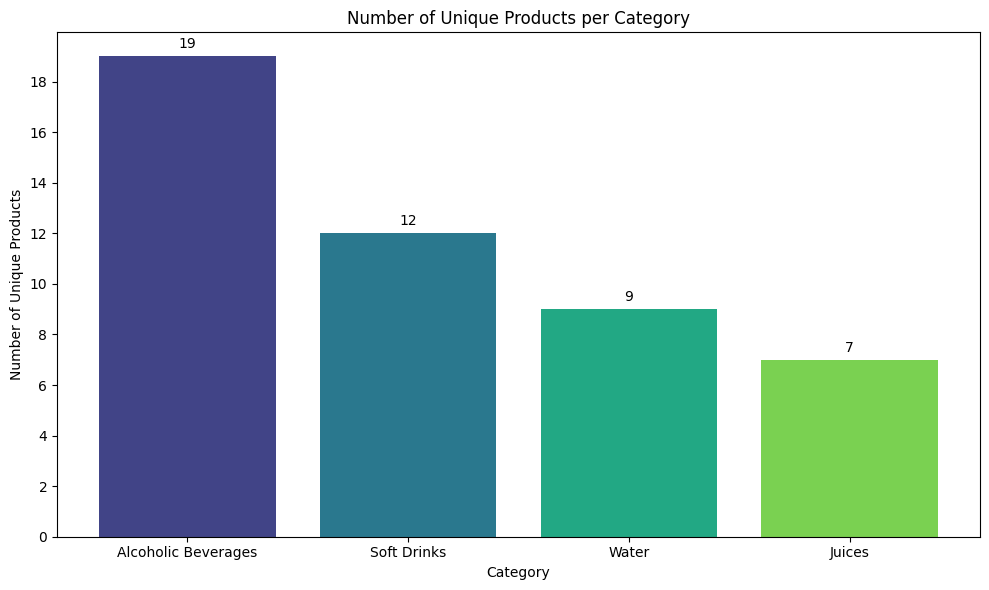

In [14]:
import matplotlib.ticker as mticker
# Calculate the number of unique products per category
unique_products_per_category = df.groupby('Category', observed=True)['Product'].nunique().sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(10, 6))
colors = sns.color_palette('viridis', n_colors=len(unique_products_per_category))
bars = plt.bar(unique_products_per_category.index, unique_products_per_category.values, color=colors)

plt.title('Number of Unique Products per Category')
plt.xlabel('Category')
plt.ylabel('Number of Unique Products')
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Add the number on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, round(yval, 0), ha='center', va='bottom')

plt.tight_layout()
plt.show();

#### Total sales and quantities by Regions

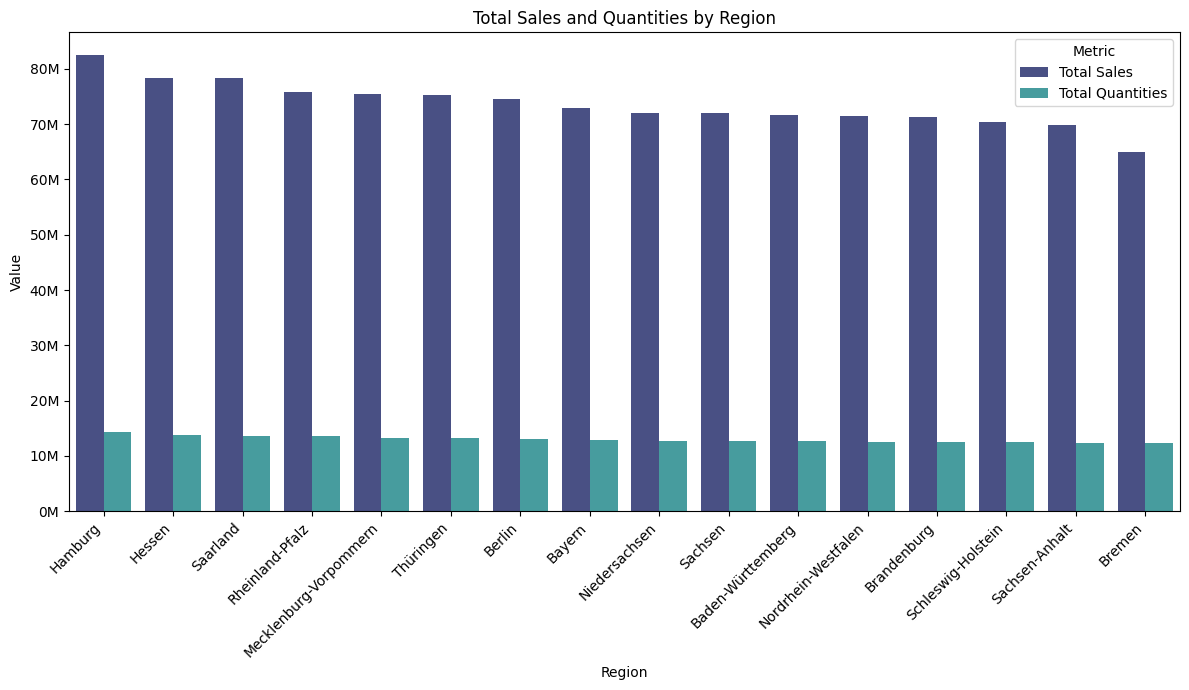

In [15]:
# Calculate total sales and quantities per region
region_sales = df.groupby('Region', observed=True)['Total_Price'].sum().sort_values(ascending=False)
region_quantities = df.groupby('Region', observed=True)['Quantity'].sum().sort_values(ascending=False)

# Create a DataFrame for plotting
region_data = pd.DataFrame({
    'Region': region_sales.index,
    'Total Sales': region_sales.values,
    'Total Quantities': region_quantities.values
})

# Melt the DataFrame to long format for easier plotting with Seaborn
region_melted = pd.melt(region_data,
                        id_vars='Region',
                        value_vars=['Total Sales', 'Total Quantities'],
                        var_name='Metric',
                        value_name='Value')

# Create the grouped bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Region', y='Value', hue='Metric', data=region_melted, palette='mako')

plt.title('Total Sales and Quantities by Region')
plt.xlabel('Region')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')

# Format the y-axis for sales (display in millions)
def format_millions(x, pos):
    return '%1.0fM' % (x * 1e-6)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))

plt.tight_layout()
plt.show()

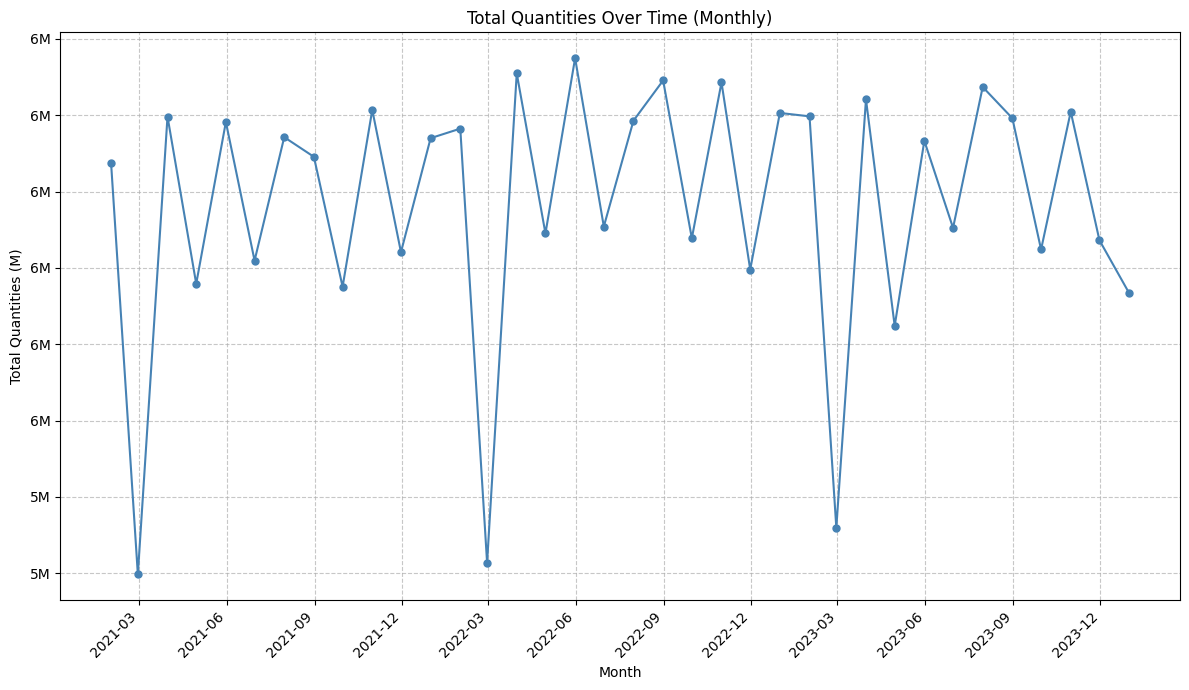

In [16]:
quantities_by_month = df.groupby(pd.Grouper(key='Order_Date', freq='ME'), observed=True)['Quantity'].sum()

# Create the figure and axes
plt.figure(figsize=(12, 7))
plt.plot(quantities_by_month.index, quantities_by_month.values, marker='o', linestyle='-', color='steelblue', markersize=5)

# Format the plot
plt.title('Total Quantities Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Total Quantities (M)')

# Format the y-axis to display in millions
def format_millions(x, pos):
    return '%1.0fM' % (x * 1e-6)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))

# Format the x-axis to display every 3 months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Total sales over Time

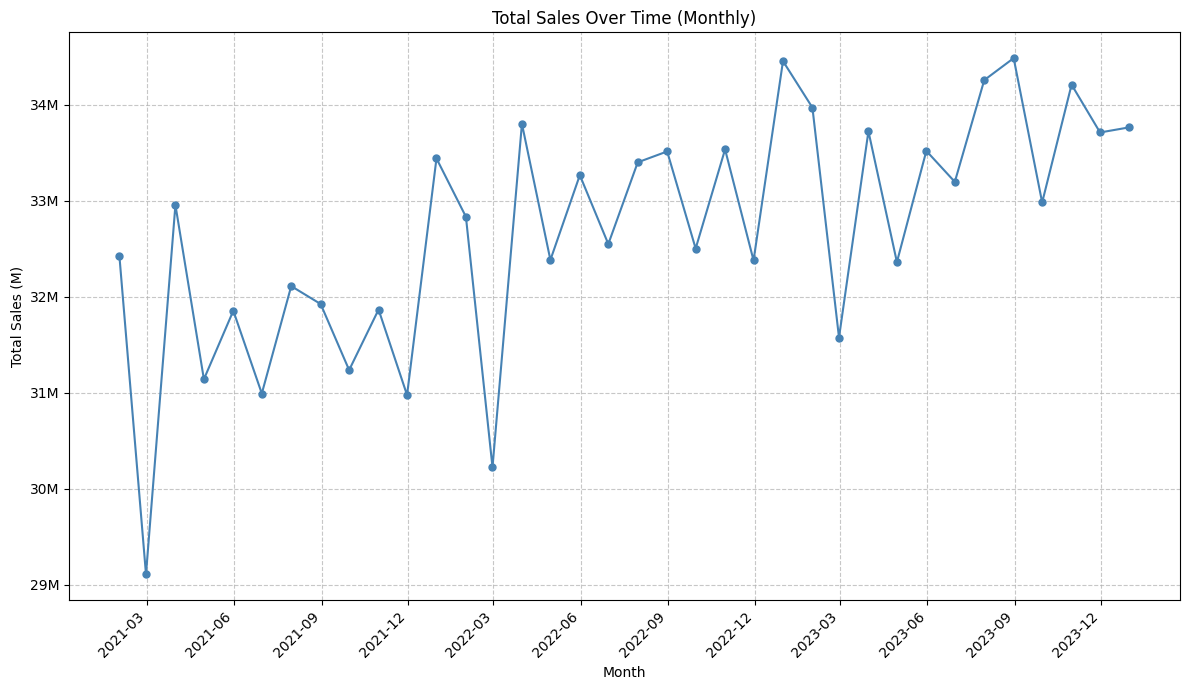

In [ ]:
sales_by_month = df.groupby(pd.Grouper(key='Order_Date', freq='ME'), observed=True)['Total_Price'].sum()

# Create the figure and axes
plt.figure(figsize=(12, 7))
plt.plot(sales_by_month.index, sales_by_month.values, marker='o', linestyle='-', color='steelblue', markersize=5)

# Format the plot
plt.title('Total Sales Over Time (Monthly)')
plt.xlabel('Month')
plt.ylabel('Total Sales (M)')

# Format the y-axis to display in millions
def format_millions(x, pos):
    return '%1.0fM' % (x * 1e-6)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))

# Format the x-axis to display every 3 months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

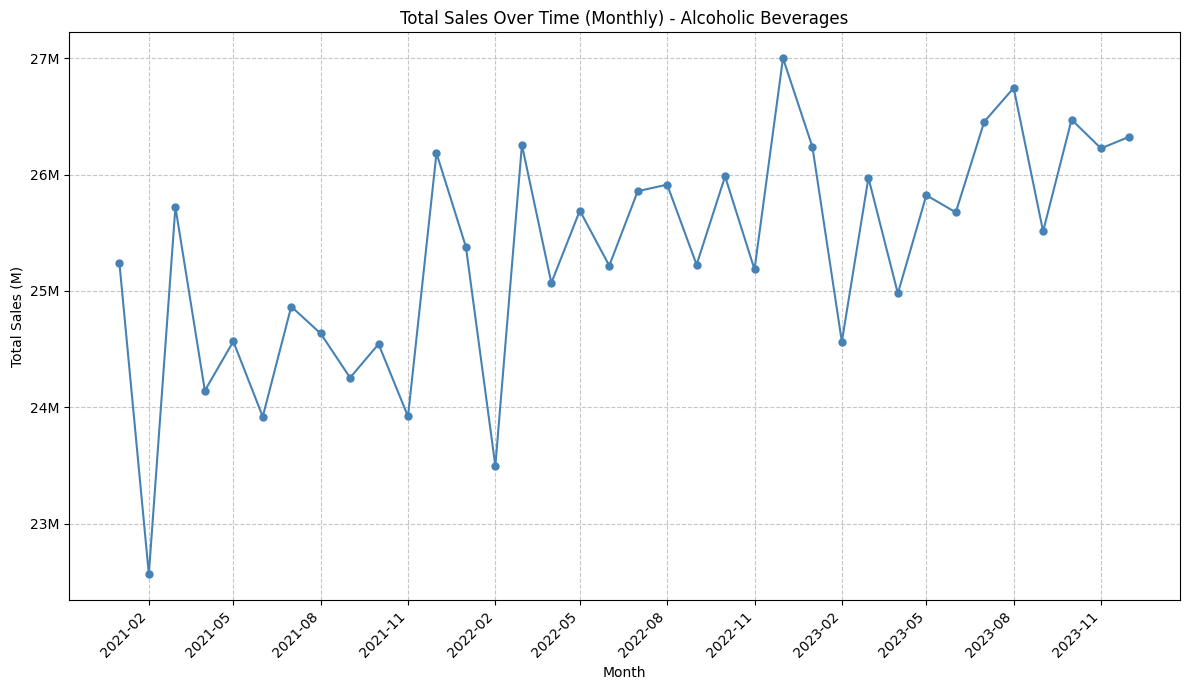

In [ ]:
# Filter data for "Alcoholic Beverages" category
alcoholic_beverages_sales = df[df['Category'] == 'Alcoholic Beverages'].groupby(pd.Grouper(key='Order_Date', freq='MS'))['Total_Price'].sum()

# Create the figure and axes
plt.figure(figsize=(12, 7))
plt.plot(alcoholic_beverages_sales.index, alcoholic_beverages_sales.values, marker='o', linestyle='-', color='steelblue', markersize=5)

# Format the plot
plt.title('Total Sales Over Time (Monthly) - Alcoholic Beverages')
plt.xlabel('Month')
plt.ylabel('Total Sales (M)')

# Format the y-axis to display in millions
def format_millions(x, pos):
    return '%1.0fM' % (x * 1e-6)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))

# Format the x-axis to display every 3 months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show();

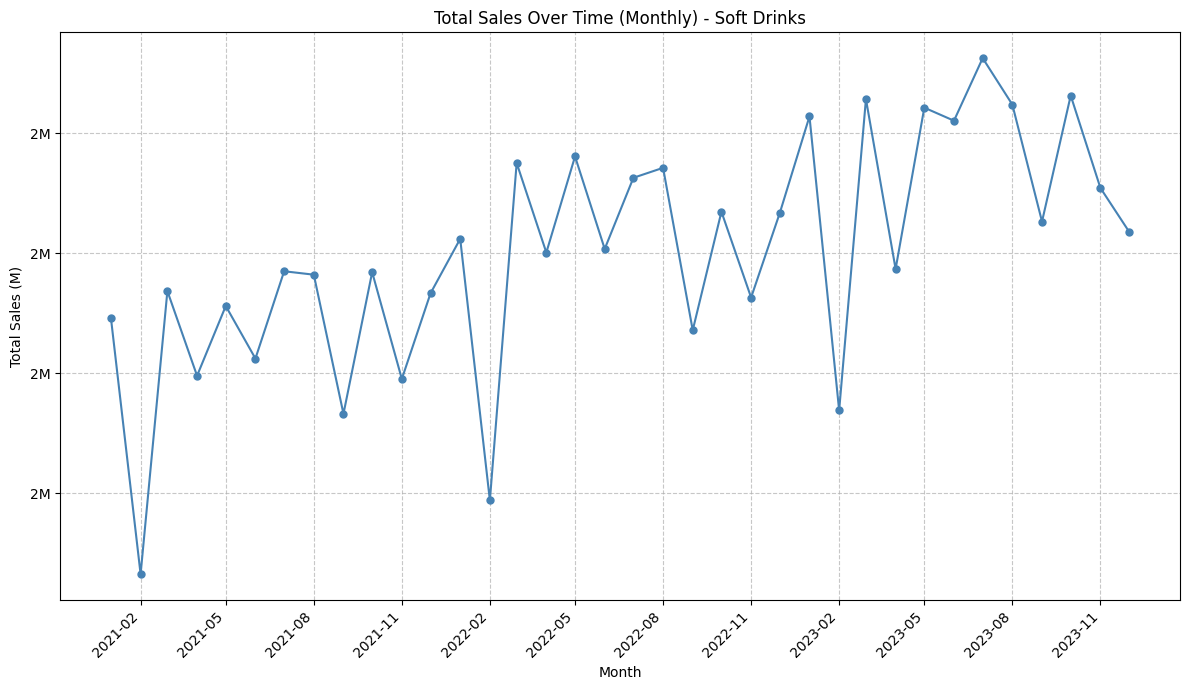

In [ ]:
# Filter data for "Soft Drinks" category
soft_drinks_sales = df[df['Category'] == 'Soft Drinks'].groupby(pd.Grouper(key='Order_Date', freq='MS'))['Total_Price'].sum()

# Create the figure and axes
plt.figure(figsize=(12, 7))
plt.plot(soft_drinks_sales.index, soft_drinks_sales.values, marker='o', linestyle='-', color='steelblue', markersize=5)

# Format the plot
plt.title('Total Sales Over Time (Monthly) - Soft Drinks')
plt.xlabel('Month')
plt.ylabel('Total Sales (M)')

# Format the y-axis to display in millions
def format_millions(x, pos):
    return '%1.0fM' % (x * 1e-6)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))

# Format the x-axis to display year and month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show();

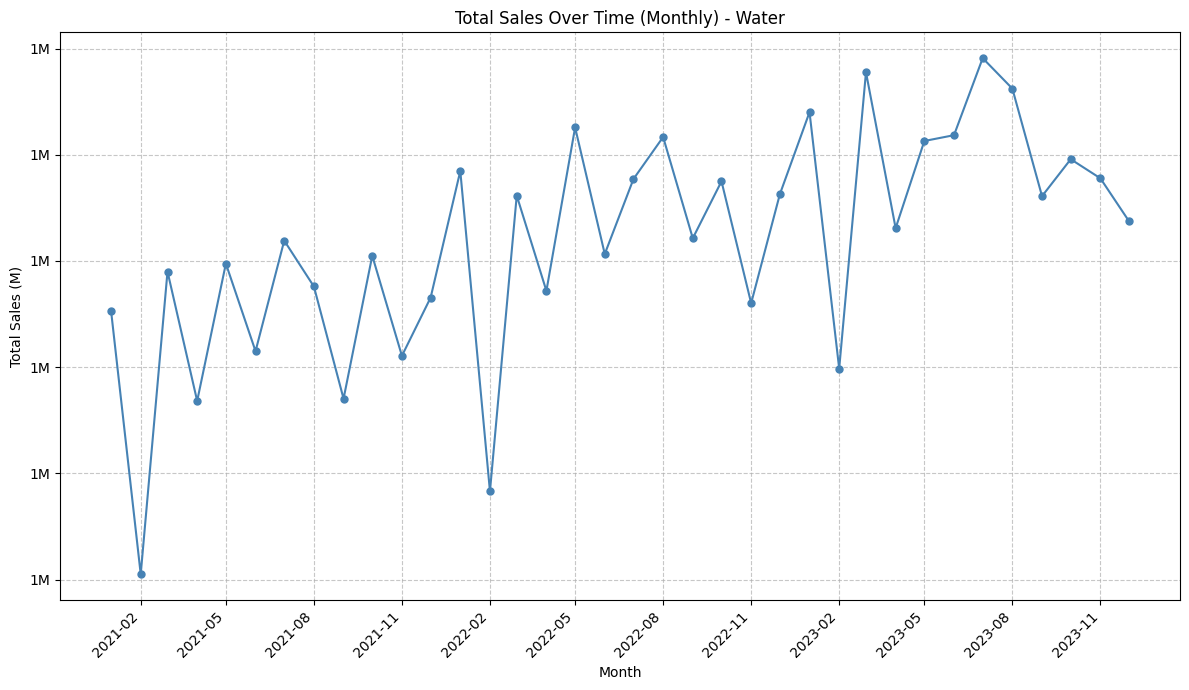

In [ ]:
# Filter data for "Water" category
water_sales = df[df['Category'] == 'Water'].groupby(pd.Grouper(key='Order_Date', freq='MS'))['Total_Price'].sum()

# Create the figure and axes
plt.figure(figsize=(12, 7))
plt.plot(water_sales.index, water_sales.values, marker='o', linestyle='-', color='steelblue', markersize=5)

# Format the plot
plt.title('Total Sales Over Time (Monthly) - Water')
plt.xlabel('Month')
plt.ylabel('Total Sales (M)')

# Format the y-axis to display in millions
def format_millions(x, pos):
    return '%1.0fM' % (x * 1e-6)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))

# Format the x-axis to display every 3 months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show();

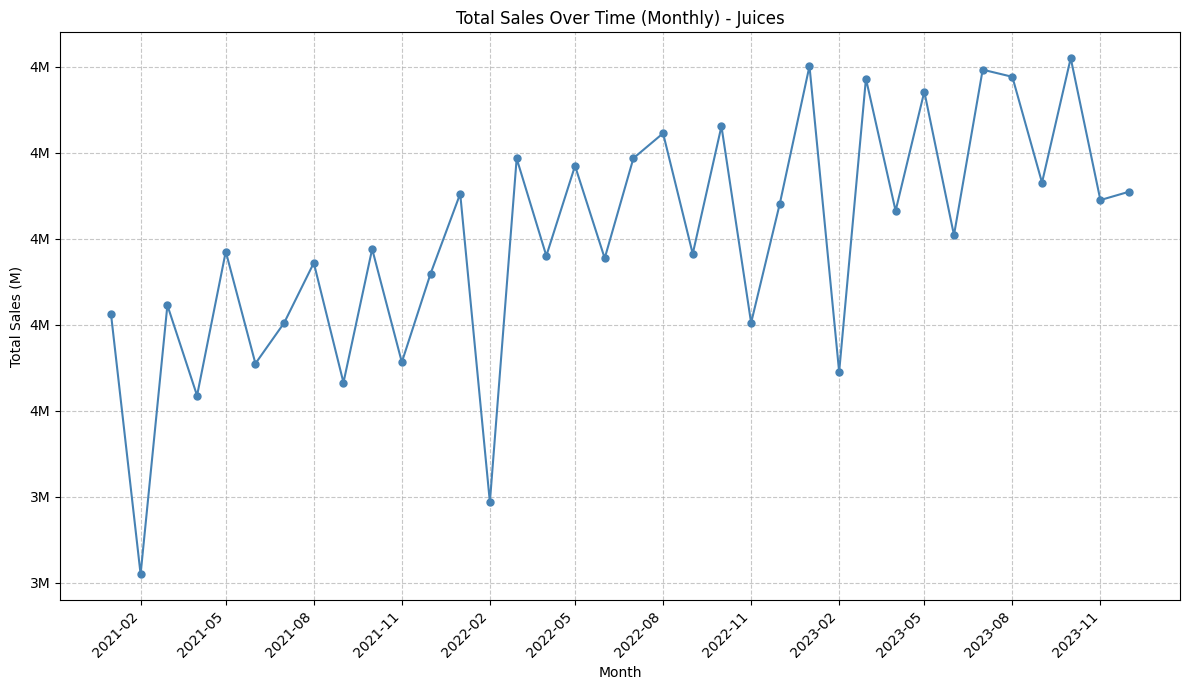

In [ ]:
# Filter data for "Juices" category
juices_sales = df[df['Category'] == 'Juices'].groupby(pd.Grouper(key='Order_Date', freq='MS'))['Total_Price'].sum()

# Create the figure and axes
plt.figure(figsize=(12, 7))
plt.plot(juices_sales.index, juices_sales.values, marker='o', linestyle='-', color='steelblue', markersize=5)

# Format the plot
plt.title('Total Sales Over Time (Monthly) - Juices')
plt.xlabel('Month')
plt.ylabel('Total Sales (M)')

# Format the y-axis to display in millions
def format_millions(x, pos):
    return '%1.0fM' % (x * 1e-6)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))

# Format the x-axis to display every 3 months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show();

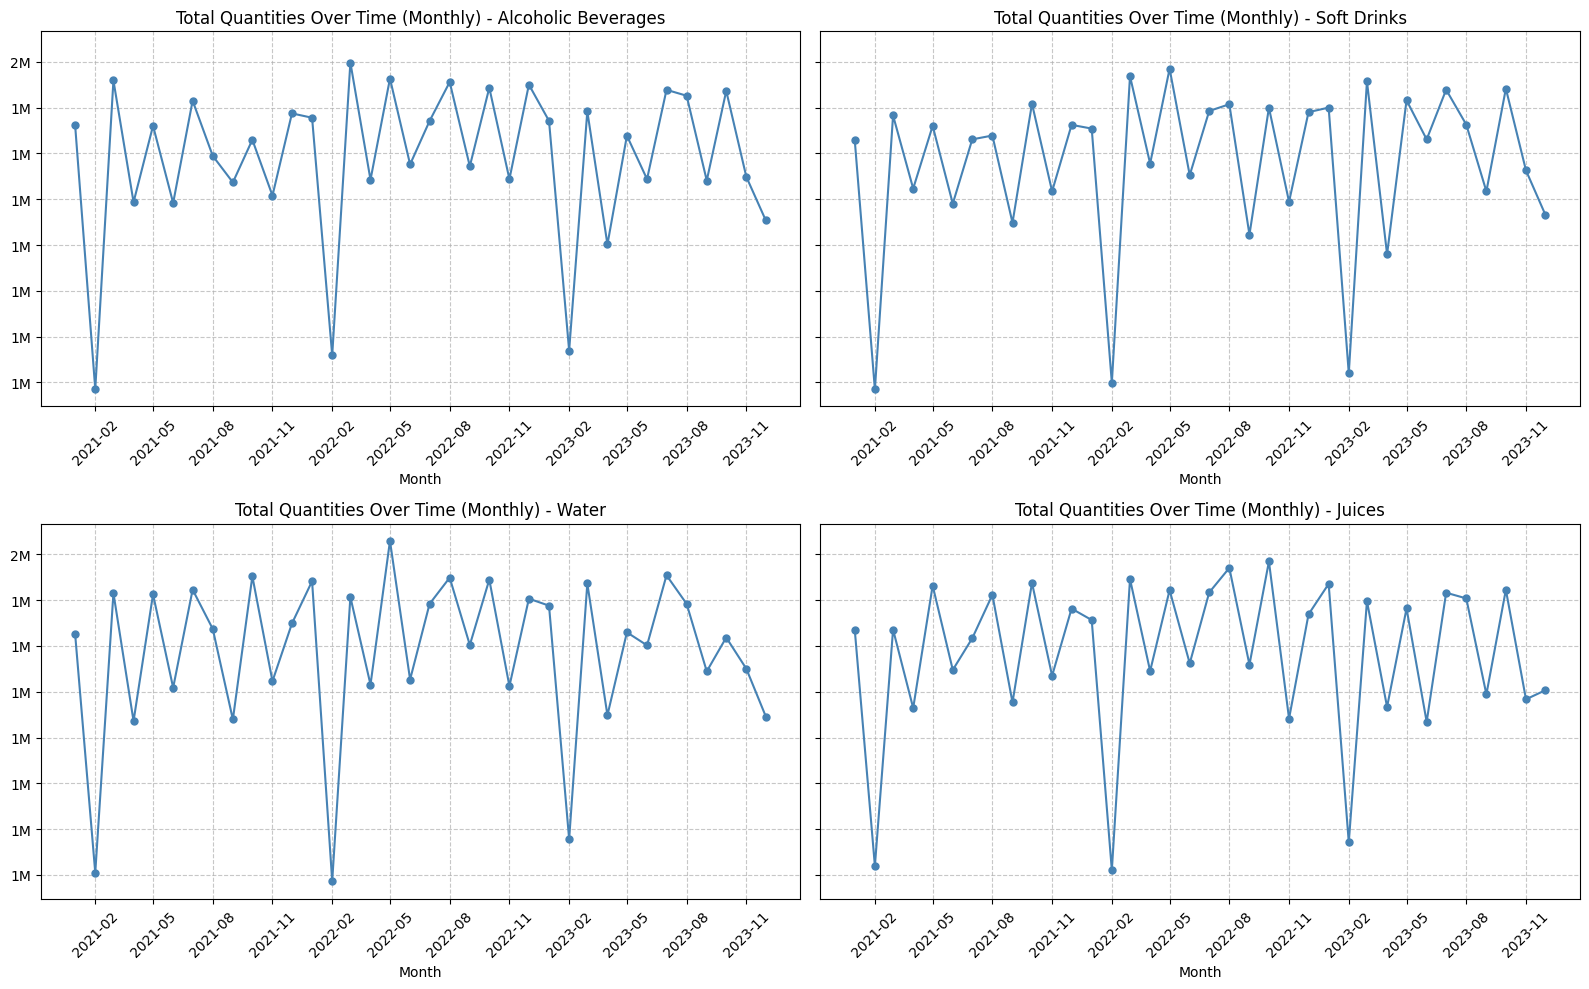

In [ ]:
# Define the categories to plot
categories = ['Alcoholic Beverages', 'Soft Drinks', 'Water', 'Juices']

# Create a figure with subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
axes = axes.flatten()  # Flatten the 2x2 array of axes for easy indexing

# Loop through each category and create a subplot
for i, category in enumerate(categories):
    # Filter data for the current category
    category_quantities = df[df['Category'] == category].groupby(pd.Grouper(key='Order_Date', freq='MS'))['Quantity'].sum()

    # Plot the data on the corresponding subplot
    axes[i].plot(category_quantities.index, category_quantities.values, marker='o', linestyle='-', color='steelblue', markersize=5)
    axes[i].set_title(f'Total Quantities Over Time (Monthly) - {category}')
    axes[i].set_xlabel('Month')
    axes[i].grid(True, linestyle='--', alpha=0.7)
    axes[i].tick_params(axis='x', rotation=45)

    # Format the y-axis to display in millions
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: '%1.0fM' % (x * 1e-6)))

    # Format the x-axis to display every 3 months
    axes[i].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

#### Total sales and total quantites by Customer id

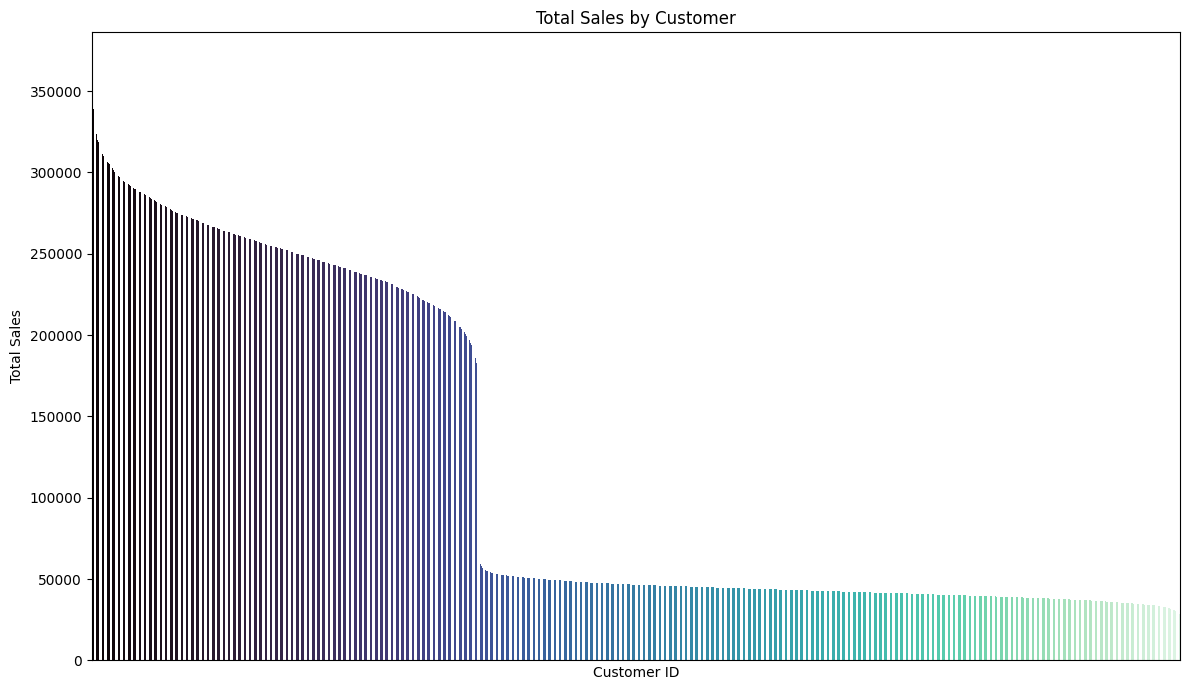

In [ ]:
sales_by_customer = df.groupby('Customer_ID', observed=True)['Total_Price'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 7))
colors = sns.color_palette('mako', n_colors=len(sales_by_customer))
sales_by_customer.plot(kind='bar', color=colors)
plt.title('Total Sales by Customer')
plt.xticks([])
plt.xlabel('Customer ID')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()


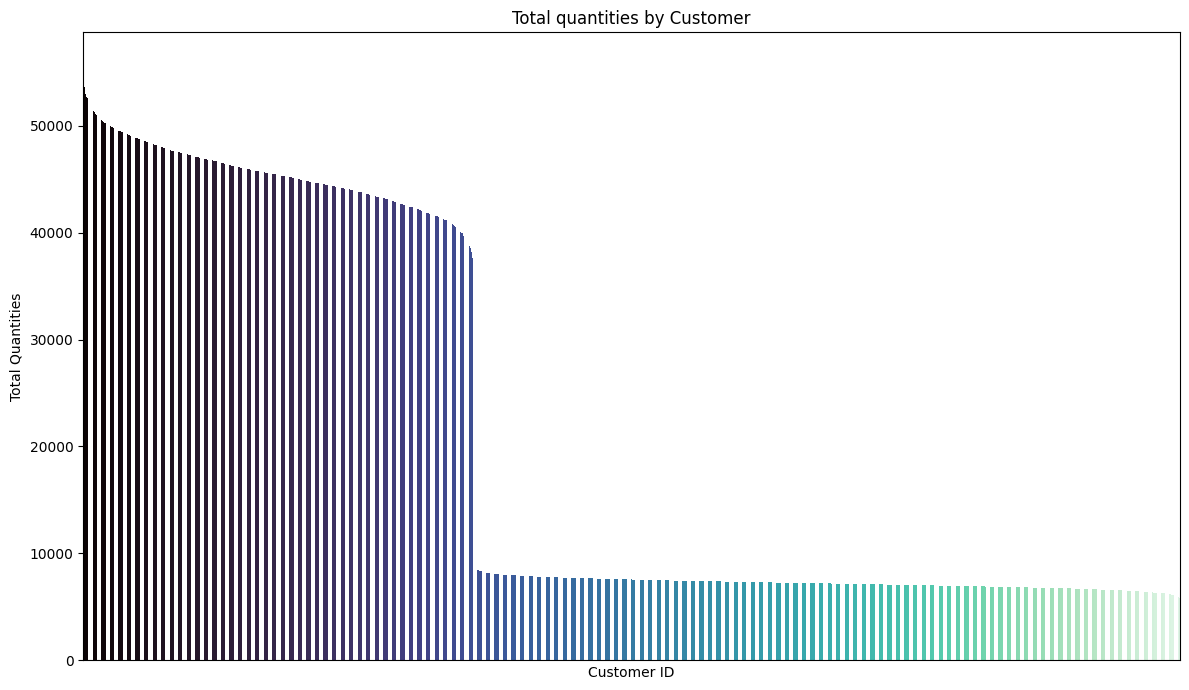

In [ ]:
quantities_by_customer = df.groupby('Customer_ID', observed=True)['Quantity'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 7))
colors = sns.color_palette('mako', n_colors=len(quantities_by_customer))
quantities_by_customer.plot(kind='bar', color=colors)
plt.title('Total quantities by Customer')
plt.xticks([])
plt.xlabel('Customer ID')
plt.ylabel('Total Quantities')
plt.tight_layout()
plt.show()

#### Price vs Quantity sold

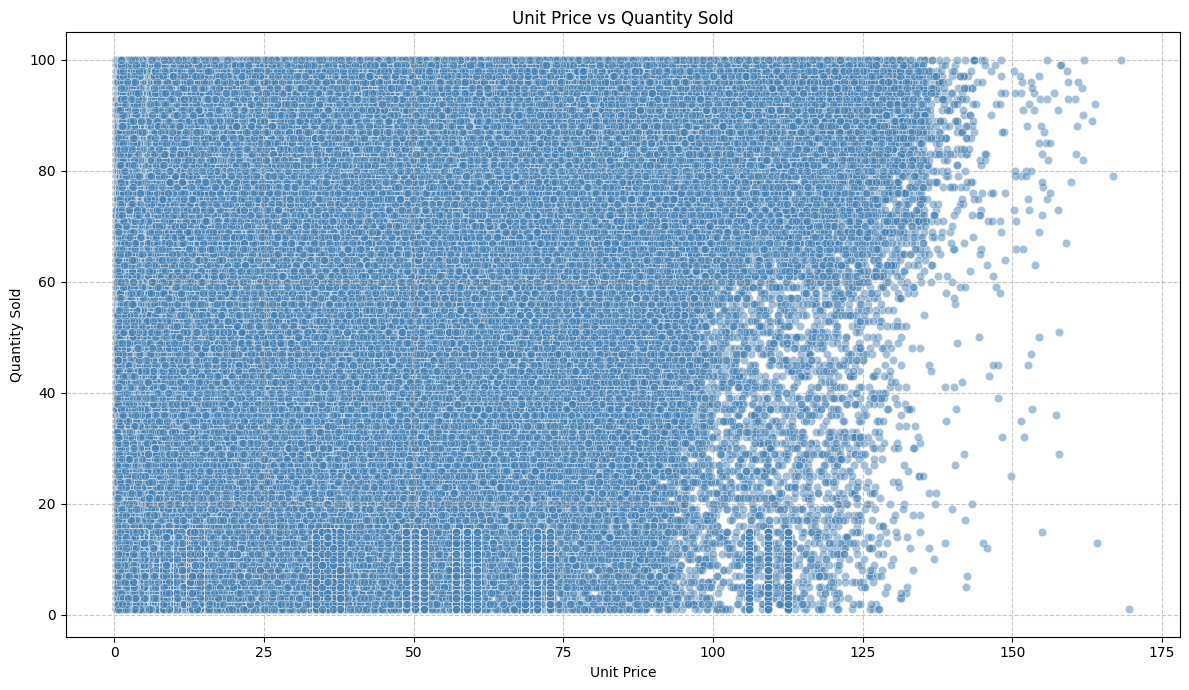

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='Unit_Price', y='Quantity', alpha=0.5, color='steelblue')
plt.title('Unit Price vs Quantity Sold')
plt.xlabel('Unit Price')
plt.ylabel('Quantity Sold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show();

#### Discount vs Quantity sold

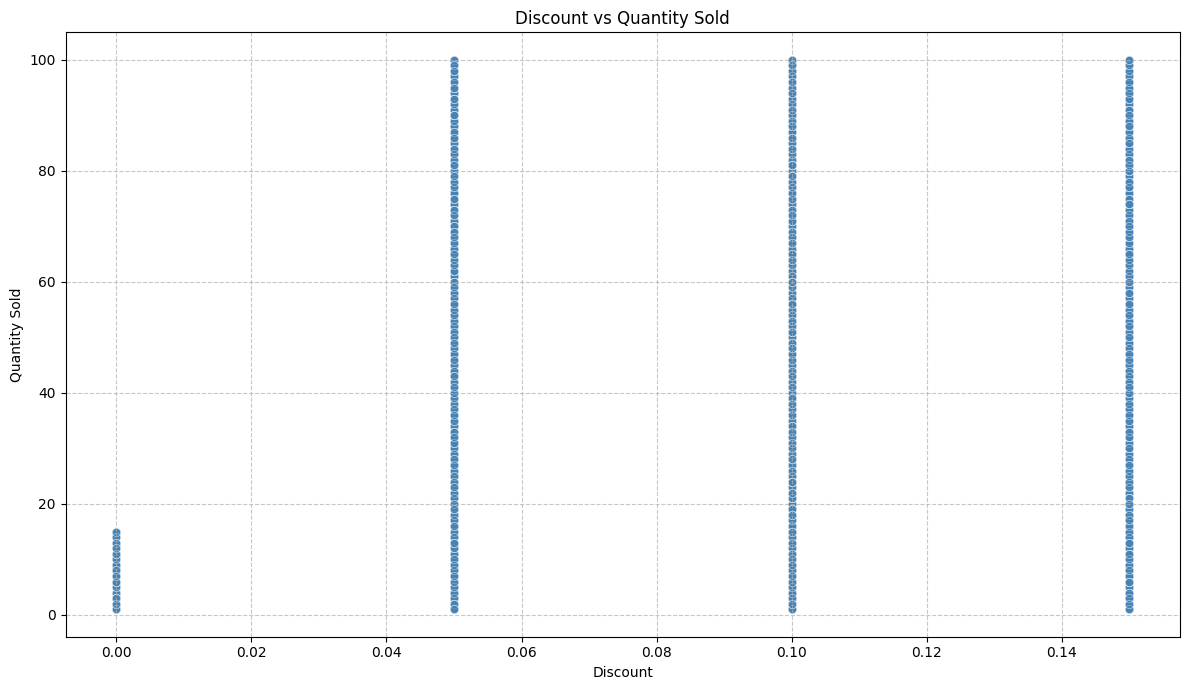

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='Discount', y='Quantity', alpha=0.5, color='steelblue')
plt.title('Discount vs Quantity Sold')
plt.xlabel('Discount')
plt.ylabel('Quantity Sold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show();